<a href="https://colab.research.google.com/github/manyanaidu28/Week6-Capstone-Telco-Churn/blob/main/Week6_Capstone_Telco_Churn_Prediction_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Week 6 - Final Capstone Project
# Customer Churn Prediction and Segmentation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Data inspection and cleaning

print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nFinal dataset shape:", df.shape)

Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Missing values after cleaning:
0

Final dataset shape: (7043, 21)


Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


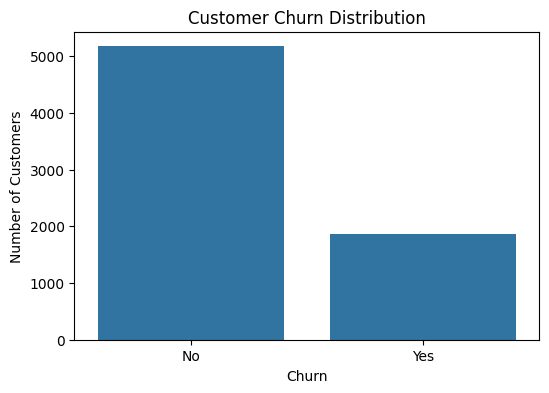

In [ ]:
# Exploratory Data Analysis

print("Basic Statistics:")
display(df.describe())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

# Churn percentage
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print("\nChurn Percentage:")
print(churn_rate)

# Plot churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Churn Rate by Contract Type:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


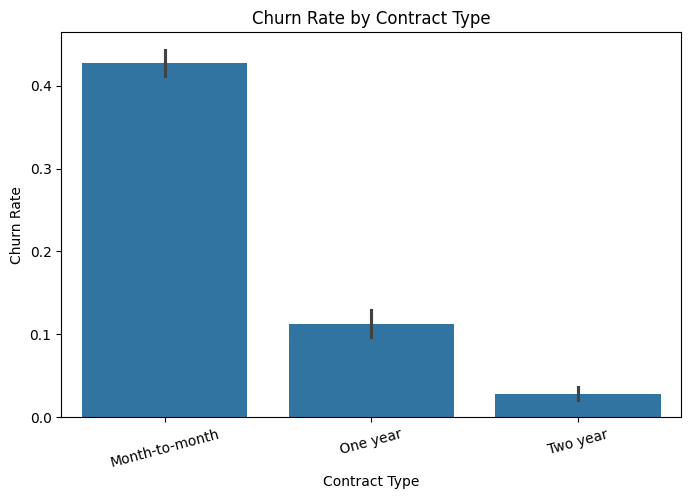

In [ ]:
# Churn Rate by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Contract Type:")
display(contract_churn)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Contract",
    y=(df["Churn"] == "Yes").astype(int)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Prepare data for supervised learning

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert Churn into numerical target
df["Churn_Encoded"] = df["Churn"].map({"No": 0, "Yes": 1})

# Select useful features
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

X = df[features]
y = df["Churn_Encoded"]

print("Features selected:", features)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features selected: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Feature shape: (7043, 4)
Target shape: (7043,)

Target distribution:
Churn_Encoded
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

Training data: (5634, 4)
Testing data: (1409, 4)

Logistic Regression model trained successfully!


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 78.42 %

Confusion Matrix:
[[935 100]
 [204 170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



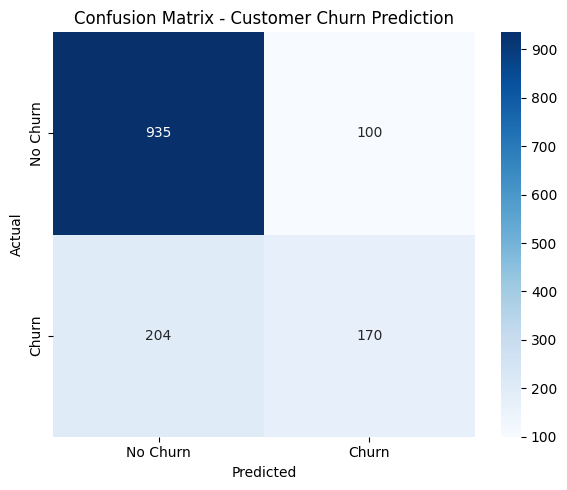

In [ ]:
# Visualize Confusion Matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

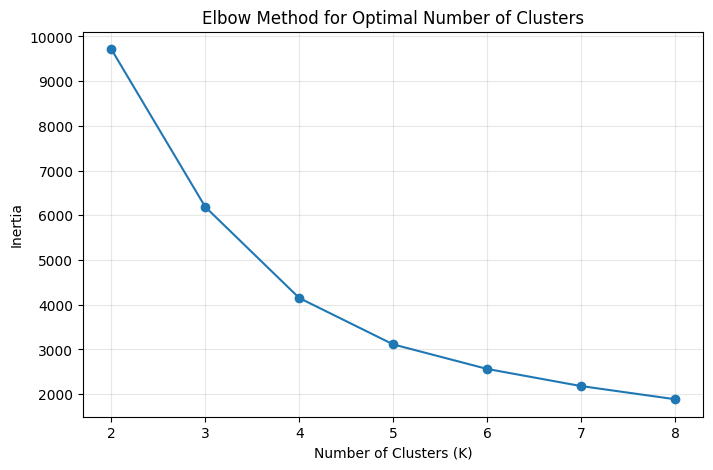

In [ ]:
# Customer Segmentation using K-Means

cluster_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_cluster = df[cluster_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Test different numbers of clusters
inertias = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertias, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

K = 2: Silhouette Score = 0.4797
K = 3: Silhouette Score = 0.4514
K = 4: Silhouette Score = 0.4720
K = 5: Silhouette Score = 0.4435
K = 6: Silhouette Score = 0.4375
K = 7: Silhouette Score = 0.4307
K = 8: Silhouette Score = 0.4336


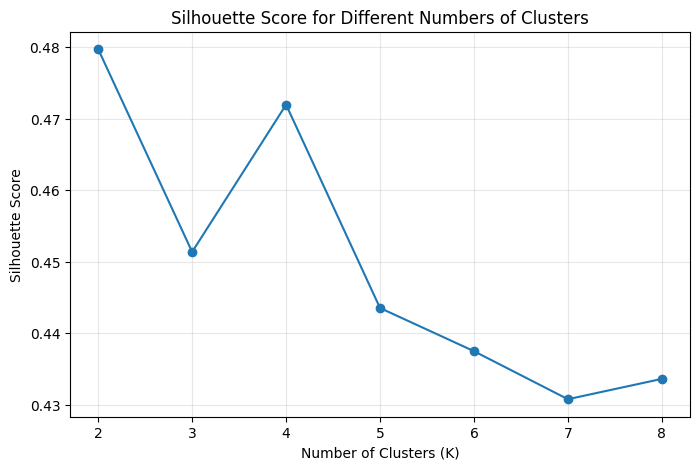

In [ ]:
# Calculate Silhouette Scores

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Display scores
for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), silhouette_scores, marker="o")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Final K-Means Customer Segmentation

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Customer segmentation completed successfully!")

print("\nCluster Sizes:")
print(df["Cluster"].value_counts().sort_index())

Customer segmentation completed successfully!

Cluster Sizes:
Cluster
0    1159
1    1904
2    1704
3    2276
Name: count, dtype: int64


In [ ]:
# Analyze characteristics of each customer cluster

cluster_summary = df.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

print("Customer Cluster Characteristics:")
display(cluster_summary)

Customer Cluster Characteristics:


,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01


In [ ]:
print("Complete Customer Cluster Summary:")
print(cluster_summary.to_string())

Complete Customer Cluster Summary:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         53.59           34.92       1836.58
1         59.53           93.31       5548.65
2         10.23           31.77        308.96
3         15.42           80.78       1253.01


In [ ]:
for cluster in cluster_summary.index:
    print(f"\nCluster {cluster}")
    print(cluster_summary.loc[cluster])


Cluster 0
tenure              53.59
MonthlyCharges      34.92
TotalCharges      1836.58
Name: 0, dtype: float64

Cluster 1
tenure              59.53
MonthlyCharges      93.31
TotalCharges      5548.65
Name: 1, dtype: float64

Cluster 2
tenure             10.23
MonthlyCharges     31.77
TotalCharges      308.96
Name: 2, dtype: float64

Cluster 3
tenure              15.42
MonthlyCharges      80.78
TotalCharges      1253.01
Name: 3, dtype: float64


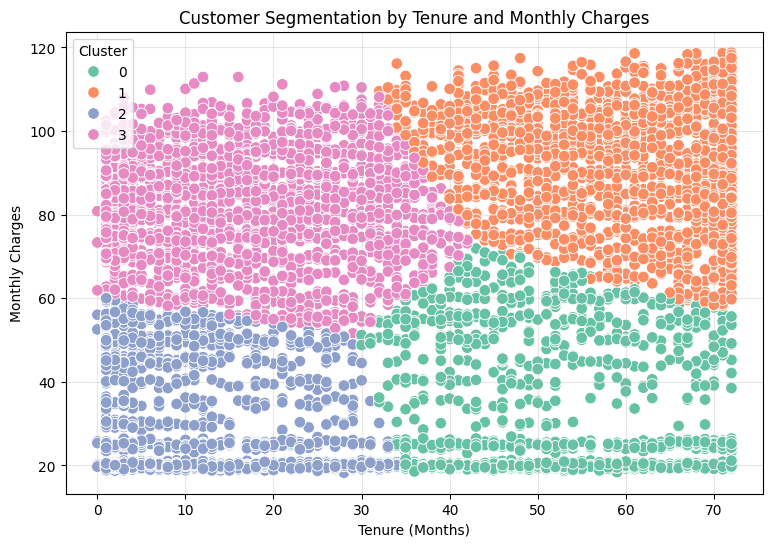

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation by Tenure and Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

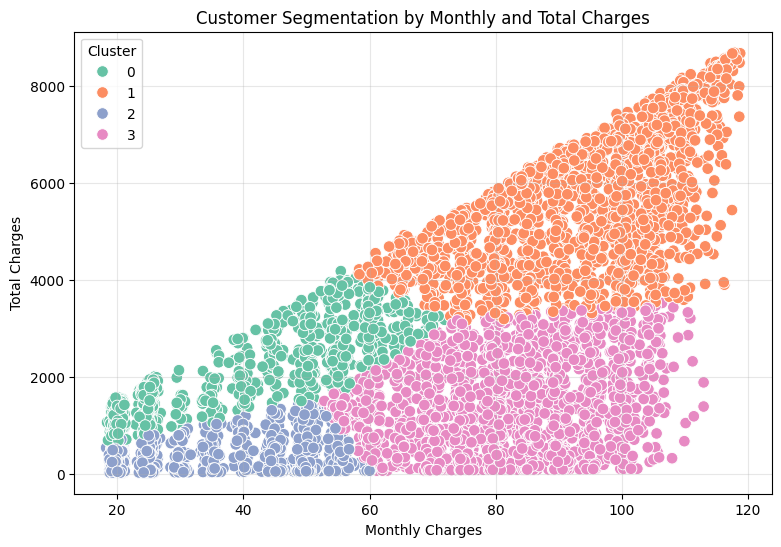

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation by Monthly and Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df.to_csv("Customer_Segmentation_Clustered.csv", index=False)

print("Clustered dataset saved successfully!")
print("File name: Customer_Segmentation_Clustered.csv")

Clustered dataset saved successfully!
File name: Customer_Segmentation_Clustered.csv


In [ ]:
cluster_churn = pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Customer Cluster (%)")
display(cluster_churn.round(2))

Churn Rate by Customer Cluster (%)


Churn,No,Yes
Cluster,,
0,95.00,5.00
1,84.61,15.39
2,75.35,24.65
3,51.76,48.24


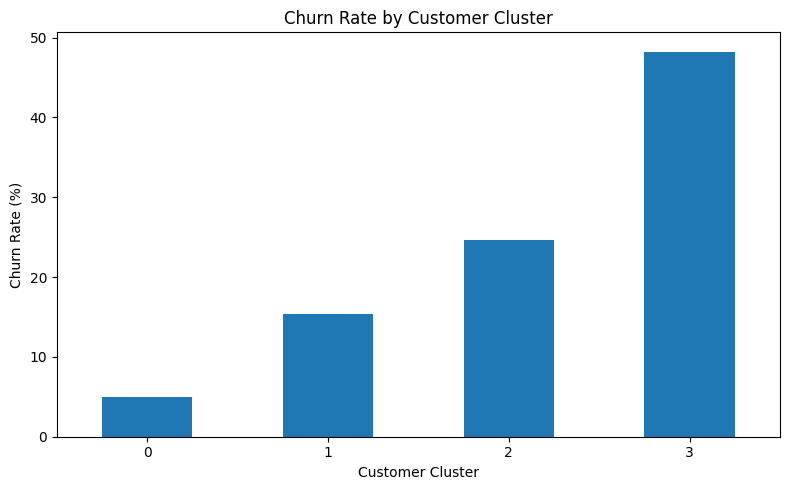

In [ ]:
cluster_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Churn Rate by Customer Cluster"
)

plt.xlabel("Customer Cluster")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("CAPSTONE PROJECT FINAL SUMMARY")
print("=" * 50)

print("Dataset: IBM Telco Customer Churn")
print("Total Customers:", len(df))
print("Churn Rate: 26.54%")
print("Logistic Regression Accuracy: 78.42%")
print("Number of Customer Clusters: 4")

print("\nCluster Churn Rates:")
print(cluster_churn.round(2))

print("\nCluster Characteristics:")
display(
    df.groupby("Cluster")[["tenure", "MonthlyCharges", "TotalCharges"]]
      .mean()
      .round(2)
)

CAPSTONE PROJECT FINAL SUMMARY
Dataset: IBM Telco Customer Churn
Total Customers: 7043
Churn Rate: 26.54%
Logistic Regression Accuracy: 78.42%
Number of Customer Clusters: 4

Cluster Churn Rates:
Churn       No    Yes
Cluster              
0        95.00   5.00
1        84.61  15.39
2        75.35  24.65
3        51.76  48.24

Cluster Characteristics:


,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01
